In [550]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import argparse
import csv
from tqdm import tqdm

# Define the relative paths
Parser = argparse.ArgumentParser()
Parser.add_argument('--DataPath', default='../Data/', help='Path to the data')
Parser.add_argument('--SavePath', default='../Data/', help='Path to save the data')
Parser.add_argument('--PerturbationRange', default=16, help='Range of warping perturbation')
Parser.add_argument('--PatchSize', default=128, help='Size of the patch')

args, unknown = Parser.parse_known_args()
dataPath = args.DataPath
savePath = args.SavePath
perturbationRange = args.PerturbationRange
patchSize = args.PatchSize



## Data Generation
To train a Convolutional Neural Network (CNN) to estimate homography between a pair of images (we call this network HomographyNet and the original paper can be found here), we need data (pairs of images) with the known homogaraphy between them. This is in-general hard to obtain as we would need the 3D movement between the pair of images to obtain the homography between them. An easier option is to generate synthetic pairs of images to train a network. But what images do we use so that the network is not baised? Simple, use images from MSCOCO dataset which contains images of a lot of objects in natural scenes. MSCOCO is quite large and it’ll take forever to train on these images. Hence, we provide a small subset of MSCOCO for you to train your HomographyNet on. This dataset is included with your starter code in the YourDirectoryID_p1\Phase2\Data\ folder, this folder contains both Train and Val images in their respective folders.

Now that you’ve downloaded the dataset, we need to generate synthetic data, i.e., pairs of images with known homography between them. Before, we generate image pairs, we need all the image pairs to be of the same size (as HomographyNet is not fully convolutional, it cannot accept image sizes of arbitrary shape). First step in generating data is to obtain a random crop of the image (called patch). Then the original image will be warped using a random homography and finally the respective patch on the warped image is extracted. While we perform this operation we need to ensure that we are not extracting the patch from outside the image after warping. An illustration is shown below.

In [551]:
# Load the names of the images so that they can be indexed

def load_image_names(source_data_path: str, folder_suffix: str) -> list[list[str], list[str]]:
    # Load the names of the images so that they can be indexed
    fullPath = os.path.join(source_data_path, folder_suffix)
    image_names = os.listdir(fullPath)
    image_names = [int(name.split(".")[0]) for name in image_names]
    image_names.sort()
    return image_names


def load_images(image_path: str, index: int, num_images: int = 1) -> np.array:
    # Load the image from the path
    images = []
    for i in range(num_images):
        image = cv2.imread(image_path + str(i + index) + ".jpg")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        images.append(image)
    if len(images) == 1:
        return images[0]
    return images


Let’s go through the steps of generating data now.

## Step 1
Obtain a random patch (PA
 of size MP×NP
) from the image (IA
) of size M×N
) with M>MP
 and N>NP
 such that all the pixels in the patch will lie within the image after warping the random extracted patch. Think about where you have to extract the patch PA
 from IA
 if maximum possible perturbation is in [−ρ,ρ]
.

## Step 2
Perform a random perturbation in the range [−ρ,ρ]
 to the corner points (top left corner, top right corner, left bottom corner and right bottom corner – not the corners in computer vision sense) of PA
 in IA
. You might also have to add a random translation amount (fixed for all 4 points) such that your network would work for translated images as well. The random perturbation (without translation) is illustrated in the figures below.

In [559]:

def select_random_patch(img: np.array, patch_size: int, perturbation_range: int) -> tuple[np.array, tuple[int, int]]:
    # Select a random patch from the image
    # Make sure the patch will lie in the image after the perturbation
    buffer = patch_size + perturbation_range * 2
    if buffer < img.shape[0] - buffer:
        x = np.random.randint(buffer, img.shape[0] - buffer)
    else:
        x = perturbation_range
    if buffer < img.shape[1] - buffer:
        y = np.random.randint(buffer, img.shape[1] - buffer)
    else:
        y = perturbation_range
    imgPatch: np.array = img[x:x + patch_size, y:y + patch_size]
    # Remember that x and y are switched due to how images are indexed

    patchCorner: tuple[int, int] = (x, y)
    return imgPatch, patchCorner


def apply_perturbation(rho: int, patch_corners: list[tuple[int, int]]) -> tuple[tuple[tuple[int, int]], list[int]]:
    """
    Apply a perturbation to each corner of the patch
    This gives the coordinates of the new patch's edges for the new homography
    @ param perturbationSize: the size of the perturbation
    @ param patchCorners: the corners of patch to be perturbed in the format of: (0, 0), (0, 1), (1, 0), (1, 1)
    @ return: the corners of the new patch
    """
    # Random distribution between -perturbationSize and perturbationSize to get the perturbation to apply

    newCorners = []
    # Apply the perturbation to each corner
    perturbs = np.random.randint(-rho, rho, (4, 2))
    for i, (x, y) in enumerate(patch_corners):
        newCorners.append((x + perturbs[i][0], y + perturbs[i][1]))
    return newCorners, perturbs.flatten().tolist()


def draw_perturbation(image: np.array, patch_corners: list[tuple[int, int]],
                      perturbed_corners: list[tuple[int, int]], store_images: bool = False) -> None or np.array:
    """
    Draw the perturbation on the image
    @ param image: the image to draw the perturbation on
    @ param perturbedCorners: the corners of the perturbed patch
    @ param storeImages: whether to store the image or display it
    """
    # Draw the perturbation on the image
    image = image.copy()
    cv2.line(image, perturbed_corners[0][::-1], perturbed_corners[1][::-1], (255, 0, 0), 3)
    cv2.line(image, perturbed_corners[0][::-1], perturbed_corners[3][::-1], (255, 0, 0), 3)
    cv2.line(image, perturbed_corners[1][::-1], perturbed_corners[2][::-1], (255, 0, 0), 3)
    cv2.line(image, perturbed_corners[2][::-1], perturbed_corners[3][::-1], (255, 0, 0), 3)
    # Draw the original patch
    cv2.line(image, patch_corners[0][::-1], patch_corners[1][::-1], (0, 255, 0), 3)
    cv2.line(image, patch_corners[0][::-1], patch_corners[3][::-1], (0, 255, 0), 3)
    cv2.line(image, patch_corners[1][::-1], patch_corners[2][::-1], (0, 255, 0), 3)
    cv2.line(image, patch_corners[2][::-1], patch_corners[3][::-1], (0, 255, 0), 3)

    #Remove excess black space
    y_nonzero, x_nonzero, _ = np.nonzero(image)
    image = image[np.min(y_nonzero):np.max(y_nonzero), np.min(x_nonzero):np.max(x_nonzero)]
    if store_images:
        return image
    else:
        plt.imshow(image)
        plt.show()




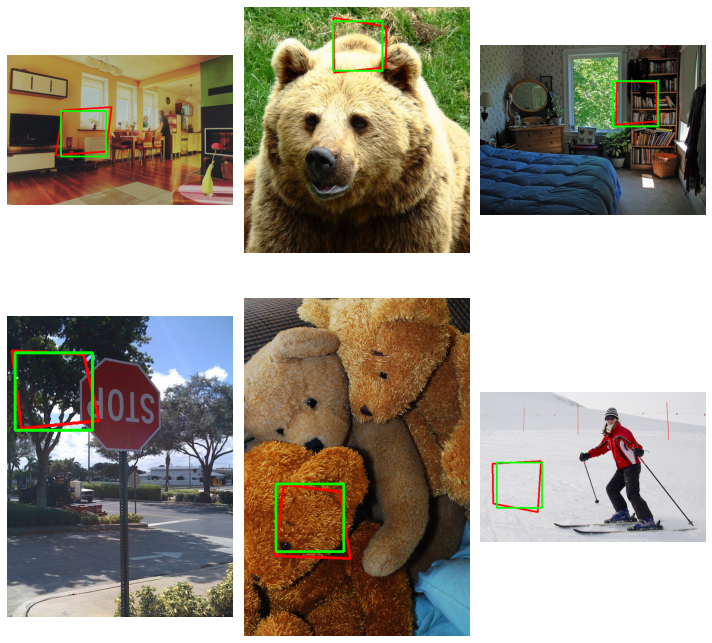

In [553]:
# Load the names of the images so that they can be indexed

imageNames = load_image_names(dataPath, "Train")
numImages = len(imageNames)

# Load first 6 images
images = load_images(dataPath + "Train/", imageNames[0], 6)

# Select a random patch from the image
drawn = []
for image in images:
    imgPatch, topCorner = select_random_patch(image, patchSize, perturbationRange)

    patchCorners = [(topCorner[0], topCorner[1]),  # Top-left
                    (topCorner[0] + patchSize, topCorner[1]),  # Top-right
                    (topCorner[0] + patchSize, topCorner[1] + patchSize),  # Bottom-right
                    (topCorner[0], topCorner[1] + patchSize)]  # Bottom-left

    # Apply a perturbation to each corner of the patch
    perturbedCorners, _ = apply_perturbation(perturbationRange, patchCorners)
    # Draw the perturbation on the image
    drawn_img = draw_perturbation(image, patchCorners, perturbedCorners, True)
    drawn.append(drawn_img)

# plot the images
fig, ax = plt.subplots(2, 3, figsize=(10, 10))
ax = ax.ravel()
for i in range(6):
    ax[i].imshow(drawn[i])
    ax[i].axis("off")
plt.tight_layout()
plt.show()



As mentioned in the last figure, we want to extract data such that we add minimal amount of extra data and we don’t want to mask anything or add black pixels (pixels outside image assuming zero padding). In order to do this, we’ll warp the image IA
 with the inverse of homography between CA
 and CB
 (denoted by HAB
), i.e., which is the homography between CB
 and CA
 (denoted by HBA
). Use cv2.getPerspectiveTransform and np.linalg.inv to implement this part.

## Step 3
Use the value of HBA
 to warp IA
 and obtain IB
. Use cv2.warpPerspective to implement this part. Now, we can extract the patch PB
 using the corners in CA
 (work the math out and convince yourself why this is true).


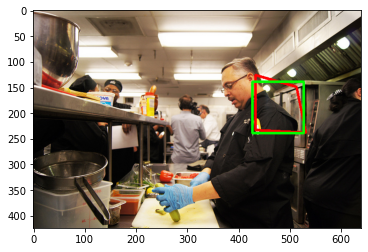

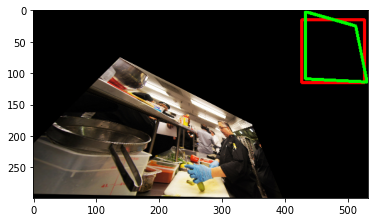

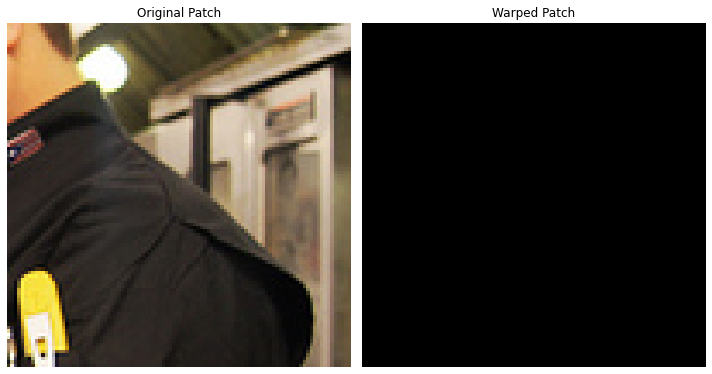

In [563]:
def obtain_homography(patch_corners: list[tuple[int, int]], perturbed_corners: list[tuple[int, int]]) -> np.array:
    """
    Obtain the homography between the two patches
    @ param patchCorners: the corners of the original patch
    @ param perturbedCorners: the corners of the perturbed patch
    """
    # Obtain the homography between the two patches
    original = np.array(patch_corners).reshape(-1, 1, 2).astype(np.float32)
    perturbed = np.array(perturbed_corners).reshape(-1, 1, 2).astype(np.float32)
    H = cv2.getPerspectiveTransform(original, perturbed)
    return H


def warp_image(img: np.array, H: np.array, show: bool = False) -> np.array:
    """
    Warp the image using the inverse homography
    @ param image: the image to warp
    @ param H: the homography to warp the image
    """
    # Warp the image using the homography
    h1, w1 = img.shape[0], img.shape[1]
    warped_img = cv2.warpPerspective(img, H, (w1, h1), flags=cv2.INTER_LINEAR)
    if show:
        plt.imshow(warped_img)
        plt.show()

    return warped_img


def extract_patch(img: np.array, patch_size: int, patchCorner: tuple[int, int]) -> np.array:
    # Extract the patch from the image
    x, y = patchCorner
    imgPatch = img[x:x + patch_size, y:y + patch_size]
    return imgPatch


def validate_homography(img: np.array, H: np.array, patch_corners: list[tuple[int, int]],
                        perturbed_corners: list[tuple[int, int]]) -> None:
    """
    Validate the homography by warping the image and extracting the patch
    """
    inv_H = np.linalg.inv(H)
    warped_img = warp_image(img, inv_H)
    # Make the translation matrix based on the corner offset due to the image warping

    # Apply the translation and inverse to the perturbed corners to get the dewarped perturbed corners
    dewarped_perturbed = cv2.perspectiveTransform(np.array([perturbed_corners], dtype=np.float32), inv_H)
    dewarped_perturbed = dewarped_perturbed.astype(np.int32).tolist()[0]

    # Apply the translation and homography to the patch corners to get the warped corners
    warped_corners = cv2.perspectiveTransform(np.array([patch_corners], dtype=np.float32), H)
    warped_corners = warped_corners.astype(np.int32).tolist()[0]

    draw_perturbation(warped_img, warped_corners, dewarped_perturbed)


# Load first image
image = load_images(dataPath + "Train/", np.random.randint(0, numImages))

# Select a random patch from the image
patchSize = 100
drawn = []


imgPatch, topCorner = select_random_patch(image, patchSize, perturbationRange)

patchCorners = [(topCorner[0], topCorner[1]),  # Top-left
                (topCorner[0] + patchSize, topCorner[1]),  # Top-right
                (topCorner[0] + patchSize, topCorner[1] + patchSize),  # Bottom-right
                (topCorner[0], topCorner[1] + patchSize)]  # Bottom-left

# Apply a perturbation to each corner of the patch
perturbedCorners, _ = apply_perturbation(perturbationRange, patchCorners)
# Draw the perturbation on the image
draw_perturbation(image, patchCorners, perturbedCorners)

homography = obtain_homography(patchCorners, perturbedCorners)

validate_homography(image, homography, patchCorners, perturbedCorners)

warped = warp_image(image, np.linalg.inv(homography), False)

warped_patch = extract_patch(warped, patchSize, topCorner)

if warped_patch.shape != imgPatch.shape:
    print("Patch size mismatch")

#plot the patches
fig, ax = plt.subplots(1, 2, figsize=(10, 10))
ax = ax.ravel()
ax[0].imshow(imgPatch)
ax[0].axis("off")
ax[0].set_title("Original Patch")
ax[1].imshow(warped_patch)
ax[1].axis("off")
ax[1].set_title("Warped Patch")
plt.tight_layout()
plt.show()

In [555]:
# Function to generate data
# Loops through the dataset a few times to get a good amount of data based on random sampling
def generate_data(imgPath: str, savePath: str, patchSize: int, rho:int ):
    # Load the names of the images so that they can be indexed
    original_path = os.path.join(savePath, "Original/")
    warped_path = os.path.join(savePath, "Warped/")
    csv_path = "ground_truth.csv"
    return
    if not os.path.exists(original_path):
        os.makedirs(original_path)
    if not os.path.exists(warped_path):
        os.makedirs(warped_path)

    csvWriter = csv.writer(open(os.path.join(savePath, csv_path), "w"))
    csvWriter.writerow(["ImageName", "GroundTruth"])
    imageNames = load_image_names(dataPath, "Train")

    for idx in tqdm(imageNames):
        image = load_images(imgPath, idx)
        for repeat in range(10):
            img_patch, topCorner = select_random_patch(image, patchSize, rho)

            patch_corners = [(topCorner[0], topCorner[1]),  # Top-left
                            (topCorner[0] + patchSize, topCorner[1]),  # Top-right
                            (topCorner[0] + patchSize, topCorner[1] + patchSize),  # Bottom-right
                            (topCorner[0], topCorner[1] + patchSize)]  # Bottom-left
            # Apply a perturbation to each corner of the patch
            perturbed_corners, perturbations = apply_perturbation(rho, patch_corners)
            homography = obtain_homography(patch_corners, perturbed_corners)
            warped = warp_image(image, np.linalg.inv(homography), False)
            warped_patch = extract_patch(warped, patchSize, topCorner)

            if warped_patch.shape != img_patch.shape:
                continue

            cv2.imwrite(original_path + str(idx) + "_" + str(repeat) + "_normal.png",cv2.cvtColor(img_patch, cv2.COLOR_RGB2BGR))
            cv2.imwrite(warped_path + str(idx) + "_" + str(repeat) + "_warped.png", cv2.cvtColor(warped_patch, cv2.COLOR_RGB2BGR))
            csvWriter.writerow([str(idx) + "_" + str(repeat), perturbations])


generate_data(dataPath + "Train/", savePath, patchSize, perturbationRange)
